# EDA - NASA C-MAPSS

Questions we need to answer before building the RUL models.

In [1]:
import sys
sys.path.append("..")
# print(sys.executable)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from src.data import load_subset, load_test_rul, SENSOR_COLS, SETTING_COLS

## Q1. How much data do we have, and is anything missing?

In [2]:
for s in ["FD001", "FD002", "FD003", "FD004"]:
    tr, te = load_subset(s)
    print(s, "| train engines:", tr.unit.nunique(), "rows:", len(tr),
          "| test engines:", te.unit.nunique(), "rows:", len(te),
          "| missing values:", tr.isna().sum().sum() + te.isna().sum().sum())

FD001 | train engines: 100 rows: 20631 | test engines: 100 rows: 13096 | missing values: 0
FD002 | train engines: 260 rows: 53759 | test engines: 259 rows: 33991 | missing values: 0
FD003 | train engines: 100 rows: 24720 | test engines: 100 rows: 16596 | missing values: 0
FD004 | train engines: 249 rows: 61249 | test engines: 248 rows: 41214 | missing values: 0


In [3]:
train, test = load_subset("FD001")
train.head()

,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


**Answer:** FD001 and FD003 have 100 training engines each, FD002 and FD004 have about 250 each.
There are no missing values, so no imputation is needed. We start with FD001 because it is the simplest.

## Q2. How long do engines last?

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


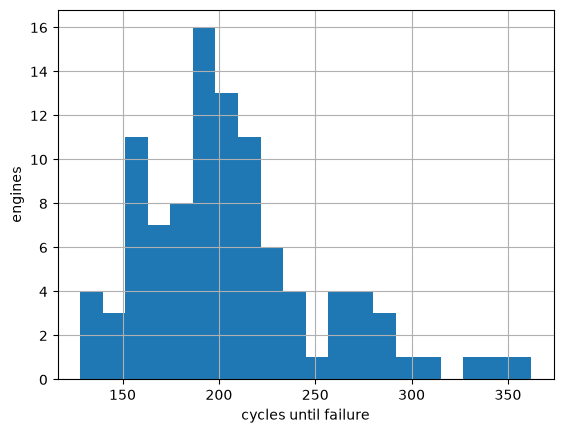

In [4]:
life = train.groupby("unit")["cycle"].max()
print(life.describe())

life.hist(bins=20)
plt.xlabel("cycles until failure")
plt.ylabel("engines")
plt.show()

**Answer:** between 128 and 362 cycles (median 199). Lifetimes vary a lot, so the cycle number alone
can't tell us when an engine will fail. The model has to use the sensor readings.

## Q3. Which sensors are useless?

In [5]:
for s in ["FD001", "FD002", "FD003", "FD004"]:
    df, _ = load_subset(s)
    n = df[SENSOR_COLS].nunique()
    print(s, list(n[n <= 3].index))

FD001 ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
FD002 ['s16', 's19']
FD003 ['s1', 's5', 's16', 's18', 's19']
FD004 ['s16', 's19']


**Answer:** these sensors are constant or only take 2-3 values, so they say nothing about wear and we drop them.
For FD001 that is s1, s5, s6, s10, s16, s18, s19, leaving 14 sensors. The list is different for each subset
(FD003 keeps s6 and s10), so we compute it per subset instead of hard-coding it.

## Q4. How do the sensors change as an engine degrades?

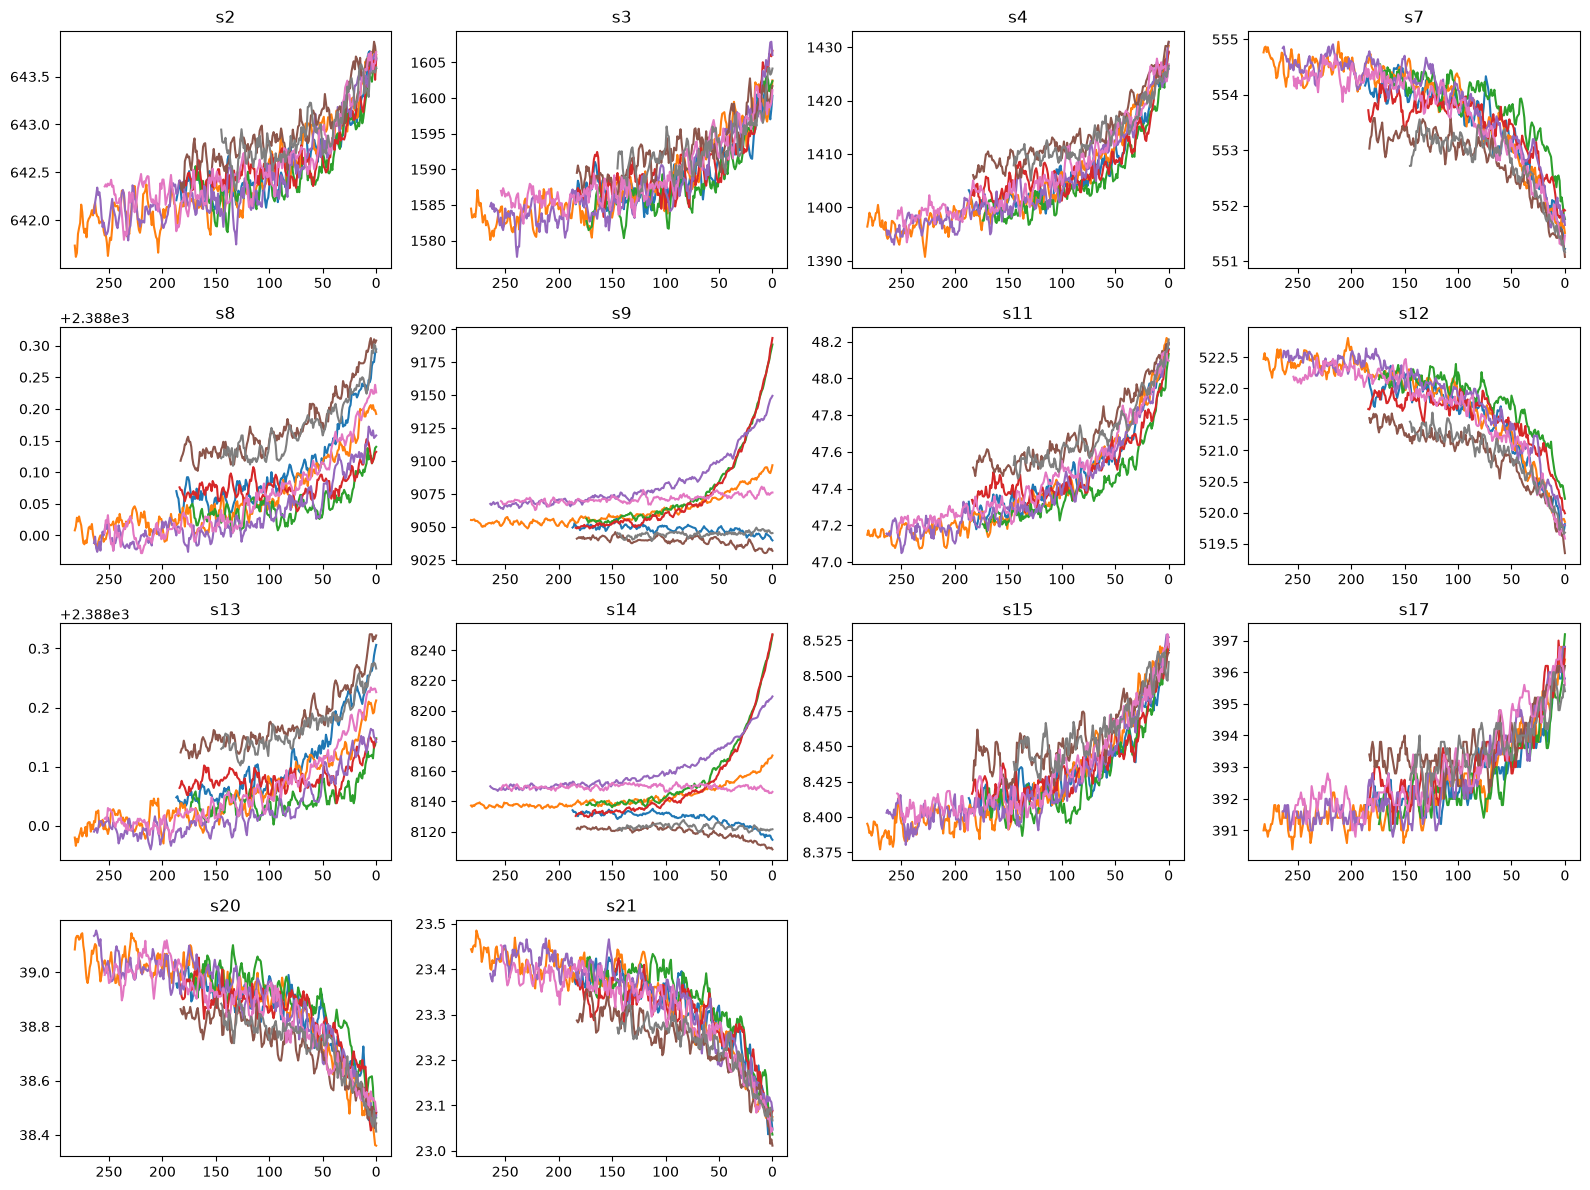

In [6]:
sensors = [c for c in SENSOR_COLS if train[c].nunique() > 3]
units = [1, 2, 3, 4, 5, 6, 7, 8]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.flat, sensors):
    for u in units:
        g = train[train.unit == u]
        ax.plot(g.RUL, g[c].rolling(5).mean())
    ax.set_title(c)
    ax.invert_xaxis()
for ax in axes.flat[len(sensors):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Answer:**
- s2, s3, s4, s8, s11, s13, s15, s17 go up as the engine wears; s7, s12, s20, s21 go down.
- s9 and s14 (core speed) behave differently from engine to engine.
- The readings are noisy, so we need smoothing or rolling-window features.

## Q5. When does degradation become visible? (What RUL cap should we use?)

**Answer (from the Q4 plots):** most sensors stay flat until roughly 100-150 cycles before failure.
Before that the sensors look the same whether RUL is 300 or 150, so the model can't tell these apart.
That's why we cap the target RUL at 125: anything above 125 is treated as "healthy".

In [7]:
true_rul = load_test_rul("FD001")
print("test engines with true RUL > 125:", (true_rul > 125).sum(), "out of", len(true_rul))

test engines with true RUL > 125: 11 out of 100


Only 11 of 100 FD001 test engines have RUL above 125, so the cap costs little on the test set.

## Q6. Which sensors are most related to RUL, and are any of them duplicates?

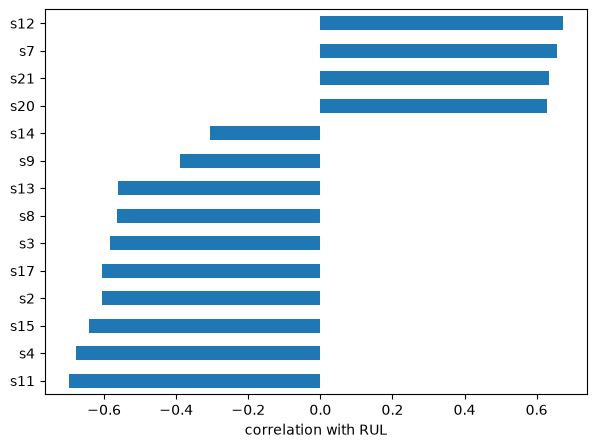

In [8]:
corr = train[sensors + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
corr.plot.barh(figsize=(7, 5))
plt.xlabel("correlation with RUL")
plt.show()

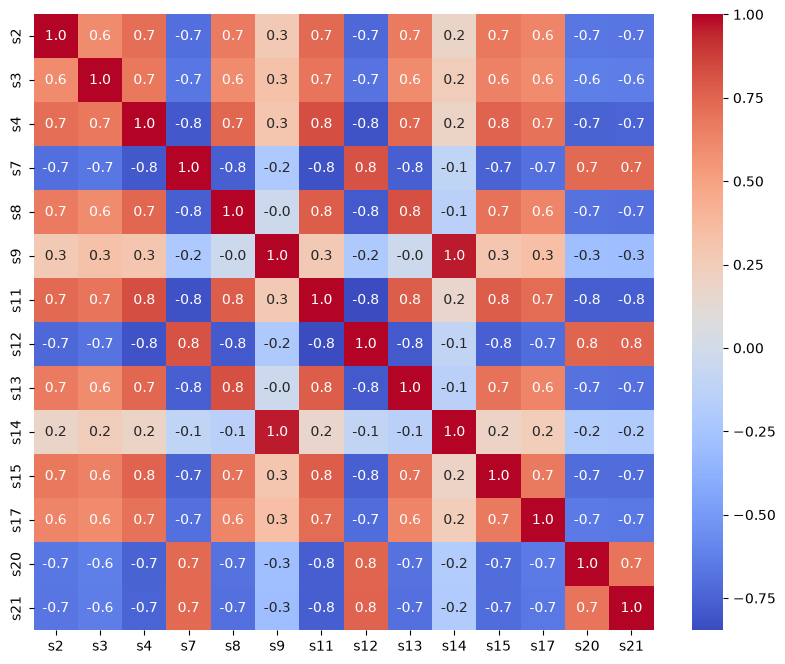

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[sensors].corr(), annot=True, fmt=".1f", cmap="coolwarm")
plt.show()

**Answer:** s11, s4, s12 and s7 are the most correlated with RUL (|r| around 0.7). s9 and s14 are the weakest.
s9 and s14 are also almost the same signal (r = 0.96). That is fine for tree models, but we should keep it in mind
when explaining the model later, because the two will share importance.

## Q7. Do operating conditions matter? (FD002)

In [10]:
train2, _ = load_subset("FD002")

km = KMeans(n_clusters=6, n_init=10, random_state=0)
train2["condition"] = km.fit_predict(train2[SETTING_COLS])

pd.DataFrame(km.cluster_centers_, columns=SETTING_COLS).round(2)

,setting_1,setting_2,setting_3
0,42.0,0.84,100.0
1,10.0,0.25,100.0
2,25.0,0.62,60.0
3,0.0,0.00,100.0
4,35.0,0.84,100.0
5,20.0,0.70,100.0


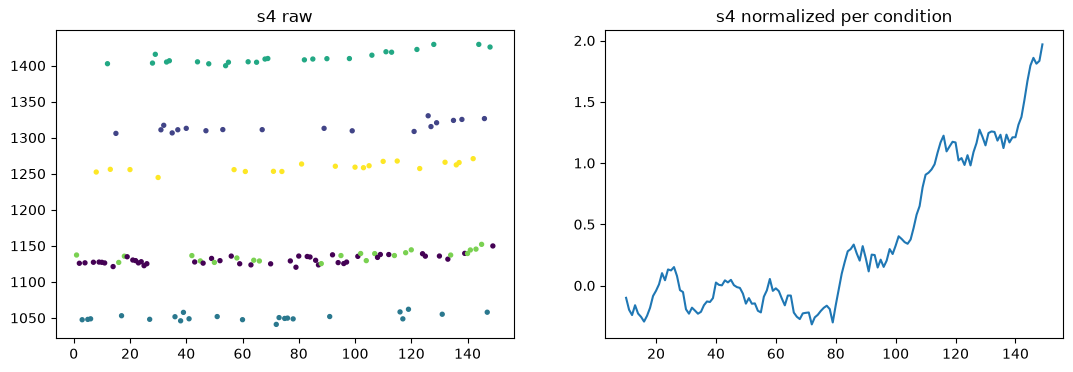

corr raw:        -0.04
corr normalized: -0.66


In [11]:
# normalize s4 separately inside each condition
train2["s4_norm"] = train2.groupby("condition")["s4"].transform(lambda x: (x - x.mean()) / x.std())

eng = train2[train2.unit == 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(eng.cycle, eng.s4, c=eng.condition, s=8)
axes[0].set_title("s4 raw")
axes[1].plot(eng.cycle, eng.s4_norm.rolling(10).mean())
axes[1].set_title("s4 normalized per condition")
plt.show()

print("corr raw:       ", round(train2.s4.corr(train2.RUL), 2))
print("corr normalized:", round(train2.s4_norm.corr(train2.RUL), 2))

**Answer:** yes, a lot. FD002 has 6 operating conditions (altitude, Mach number, throttle), and KMeans finds them easily.
The raw sensor value jumps with the condition and hides the wear. After normalizing inside each condition,
the trend shows up and the correlation with RUL goes from -0.04 to -0.66. So FD002 and FD004 need
per-condition normalization.

## Q8. Does a second fault mode change sensor behaviour? (FD003)

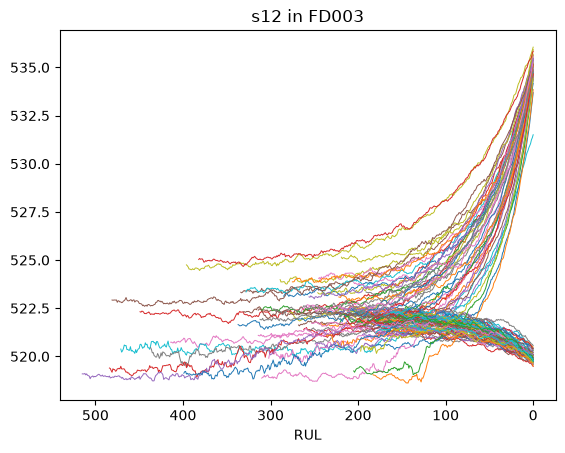

In [12]:
train3, _ = load_subset("FD003")

for u, g in train3.groupby("unit"):
    plt.plot(g.RUL, g.s12.rolling(10).mean(), lw=0.7)
plt.gca().invert_xaxis()
plt.title("s12 in FD003")
plt.xlabel("RUL")
plt.show()

**Answer:** yes. FD003 has two fault modes (HPC and fan). s12 goes up for some engines and down for others,
so the model can't assume a sensor always moves in the same direction. This makes FD003 harder than FD001
even though both have a single operating condition.

## Q9. What window length can we use?

In [13]:
for s in ["FD001", "FD002", "FD003", "FD004"]:
    _, te = load_subset(s)
    lengths = te.groupby("unit")["cycle"].max()
    print(s, "shortest test engine:", lengths.min(), "| engines with < 30 cycles:", (lengths < 30).sum())

FD001 shortest test engine: 31 | engines with < 30 cycles: 0
FD002 shortest test engine: 21 | engines with < 30 cycles: 6
FD003 shortest test engine: 38 | engines with < 30 cycles: 0
FD004 shortest test engine: 19 | engines with < 30 cycles: 11


**Answer:** a window of 30 cycles (the value used in the literature) works for every test engine in FD001 and FD003.
In FD002 (6 engines) and FD004 (11 engines) some test engines are shorter than 30, so we pad them
by repeating their first reading.

## Summary: decisions for preprocessing

| Question | Decision |
|---|---|
| Missing values? | None, no imputation |
| Useless sensors? | Drop constant sensors per subset |
| RUL target? | Cap at 125 |
| Noise? | Rolling features / windows |
| Operating conditions? | KMeans (6 clusters) + normalize per condition for FD002, FD004 |
| Window length? | 30, pad shorter test engines |